In [ ]:


import pandas as pd
import scipy
import numpy as np
from sklearn.preprocessing import MinMaxScaler
df = pd.read_csv('/content/education_job_role.csv')
print(df.head())

   candidate_id                                             skills  \
0           1.0  Python, SQL, TensorFlow, Machine Learning, Com...   
1           2.0             HTML, CSS, JavaScript, React, Teamwork   
2           3.0      Java, Spring, SQL, REST APIs, Problem Solving   
3           4.0          Figma, Adobe XD, UI/UX Design, Creativity   
4           5.0           Python, Django, JavaScript, React, Agile   

                        qualification experience_level  \
0            Master's in Data Science           Senior   
1      Bachelor's in Computer Science              Mid   
2  Bachelor's in Software Engineering           Senior   
3                Bachelor's in Design            Entry   
4        Master's in Computer Science              Mid   

                      job_role College_ID  IQ  Prev_Sem_Result  CGPA  \
0               Data Scientist        NaN NaN              NaN   NaN   
1           Frontend Developer        NaN NaN              NaN   NaN   
2            B

In [ ]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   candidate_id            951 non-null    float64
 1   skills                  960 non-null    object 
 2   qualification           948 non-null    object 
 3   experience_level        953 non-null    object 
 4   job_role                945 non-null    object 
 5   College_ID              9490 non-null   object 
 6   IQ                      9500 non-null   float64
 7   Prev_Sem_Result         9501 non-null   float64
 8   CGPA                    9524 non-null   float64
 9   Academic_Performance    9507 non-null   float64
 10  Internship_Experience   9502 non-null   object 
 11  Extra_Curricular_Score  9493 non-null   float64
 12  Communication_Skills    9501 non-null   float64
 13  Projects_Completed      9497 non-null   float64
 14  Placement               9491 non-null 

In [ ]:
df.describe()

,candidate_id,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Extra_Curricular_Score,Communication_Skills,Projects_Completed
count,951.000000,9500.000000,9501.000000,9524.000000,9507.000000,9493.000000,9501.000000,9497.000000
mean,502.883281,99.517263,7.528913,7.534129,5.546229,4.954809,5.560573,2.512583
std,289.143610,15.044420,1.444518,1.468377,2.866524,3.156536,2.901586,1.712999
min,1.000000,41.000000,5.000000,4.540000,1.000000,0.000000,1.000000,0.000000
25%,252.000000,89.000000,6.290000,6.290000,3.000000,2.000000,3.000000,1.000000
50%,504.000000,100.000000,7.540000,7.550000,6.000000,5.000000,6.000000,3.000000
75%,753.500000,110.000000,8.770000,8.770000,8.000000,8.000000,8.000000,4.000000
max,1000.000000,158.000000,10.000000,10.460000,10.000000,10.000000,10.000000,5.000000


In [ ]:

mv = df.isnull()
print(mv)

       candidate_id  skills  qualification  experience_level  job_role  \
0             False   False          False             False     False   
1             False   False          False             False     False   
2             False   False          False             False     False   
3             False   False          False             False     False   
4             False   False          False             False     False   
...             ...     ...            ...               ...       ...   
10995          True    True           True              True      True   
10996          True    True           True              True      True   
10997          True    True           True              True      True   
10998          True    True           True              True      True   
10999          True    True           True              True      True   

       College_ID     IQ  Prev_Sem_Result   CGPA  Academic_Performance  \
0            True   True             

In [ ]:

print(df.notnull())

       candidate_id  skills  qualification  experience_level  job_role  \
0              True    True           True              True      True   
1              True    True           True              True      True   
2              True    True           True              True      True   
3              True    True           True              True      True   
4              True    True           True              True      True   
...             ...     ...            ...               ...       ...   
10995         False   False          False             False     False   
10996         False   False          False             False     False   
10997         False   False          False             False     False   
10998         False   False          False             False     False   
10999         False   False          False             False     False   

       College_ID     IQ  Prev_Sem_Result   CGPA  Academic_Performance  \
0           False  False            F

In [ ]:

print(df.isnull().sum())

candidate_id              10049
skills                    10040
qualification             10052
experience_level          10047
job_role                  10055
College_ID                 1510
IQ                         1500
Prev_Sem_Result            1499
CGPA                       1476
Academic_Performance       1493
Internship_Experience      1498
Extra_Curricular_Score     1507
Communication_Skills       1499
Projects_Completed         1503
Placement                  1509
dtype: int64


In [ ]:
cleaned_df = df.dropna()
print(df)

       candidate_id                                             skills  \
0               1.0  Python, SQL, TensorFlow, Machine Learning, Com...   
1               2.0             HTML, CSS, JavaScript, React, Teamwork   
2               3.0      Java, Spring, SQL, REST APIs, Problem Solving   
3               4.0          Figma, Adobe XD, UI/UX Design, Creativity   
4               5.0           Python, Django, JavaScript, React, Agile   
...             ...                                                ...   
10995           NaN                                                NaN   
10996           NaN                                                NaN   
10997           NaN                                                NaN   
10998           NaN                                                NaN   
10999           NaN                                                NaN   

                            qualification experience_level  \
0                Master's in Data Science        

In [ ]:

cleaned_df.head()

,candidate_id,skills,qualification,experience_level,job_role,College_ID,IQ,Prev_Sem_Result,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement


In [ ]:
print(cleaned_df.columns)

Index(['candidate_id', 'skills', 'qualification', 'experience_level',
       'job_role', 'College_ID', 'IQ', 'Prev_Sem_Result', 'CGPA',
       'Academic_Performance', 'Internship_Experience',
       'Extra_Curricular_Score', 'Communication_Skills', 'Projects_Completed',
       'Placement'],
      dtype='object')


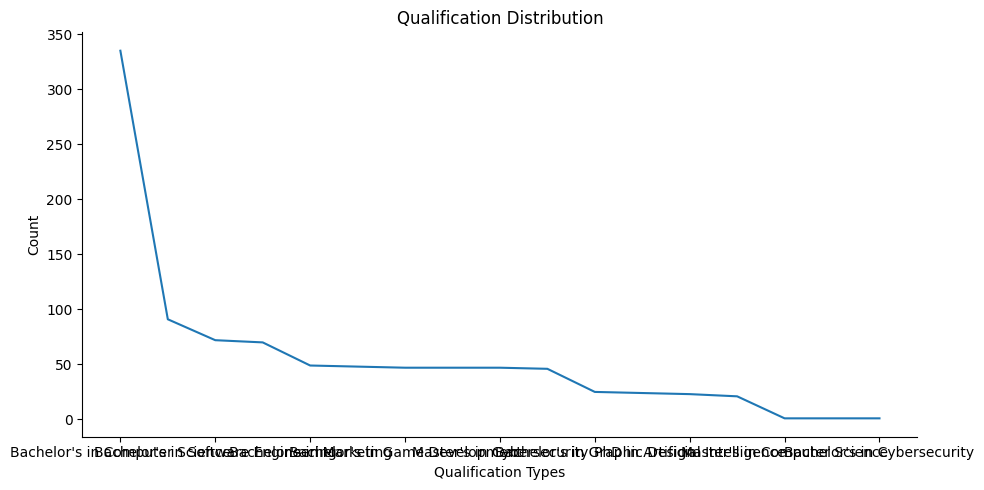

In [ ]:
df['qualification'].value_counts().plot(
    kind='line',
    figsize=(10, 5),
    title='Qualification Distribution'
)

plt.xlabel("Qualification Types")
plt.ylabel("Count")
plt.gca().spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

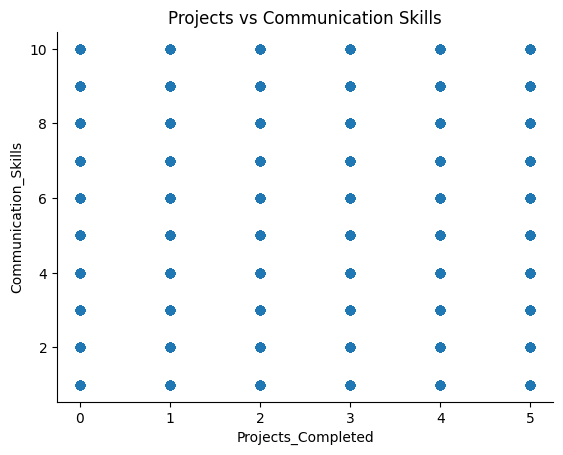

In [ ]:
df.plot(kind='scatter', x='Projects_Completed', y='Communication_Skills', s=32, alpha=.8)
plt.title("Projects vs Communication Skills")
plt.gca().spines[['top','right']].set_visible(False)
plt.show()

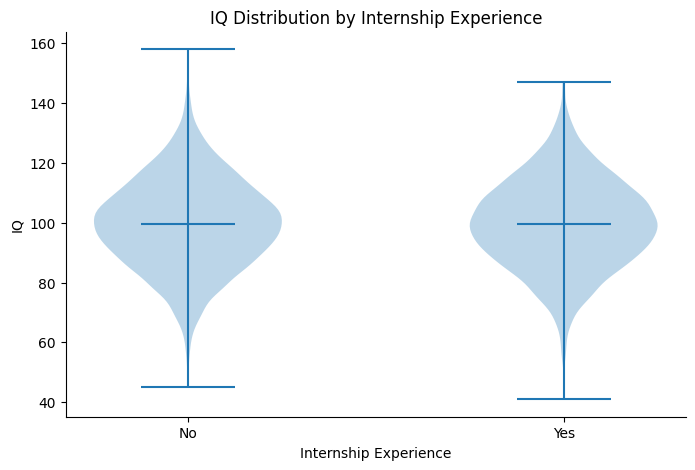

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

groups = [group['IQ'].dropna().values for name, group in df.groupby('Internship_Experience')]
labels = [name for name, group in df.groupby('Internship_Experience')]

plt.figure(figsize=(8,5))
plt.violinplot(groups, showmeans=True, showextrema=True)
plt.xticks(np.arange(1, len(labels)+1), labels)
plt.xlabel("Internship Experience")
plt.ylabel("IQ")
plt.title("IQ Distribution by Internship Experience")
plt.gca().spines[['top','right']].set_visible(False)

plt.show()


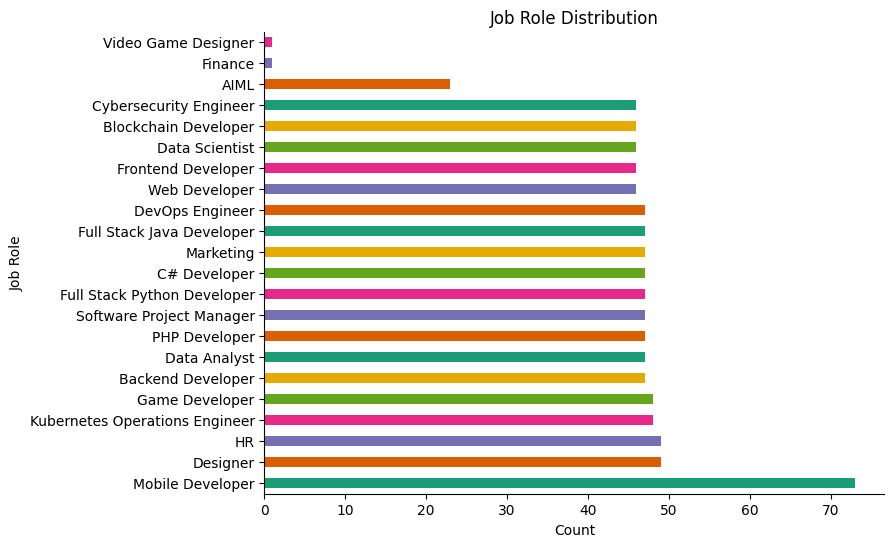

In [ ]:
from matplotlib import pyplot as plt
import seaborn as sns
import pandas as pd
role_counts = df['job_role'].value_counts()

plt.figure(figsize=(8, 6))
role_counts.plot(kind='barh', color=sns.palettes.mpl_palette('Dark2'))

plt.title("Job Role Distribution")
plt.xlabel("Count")
plt.ylabel("Job Role")
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()

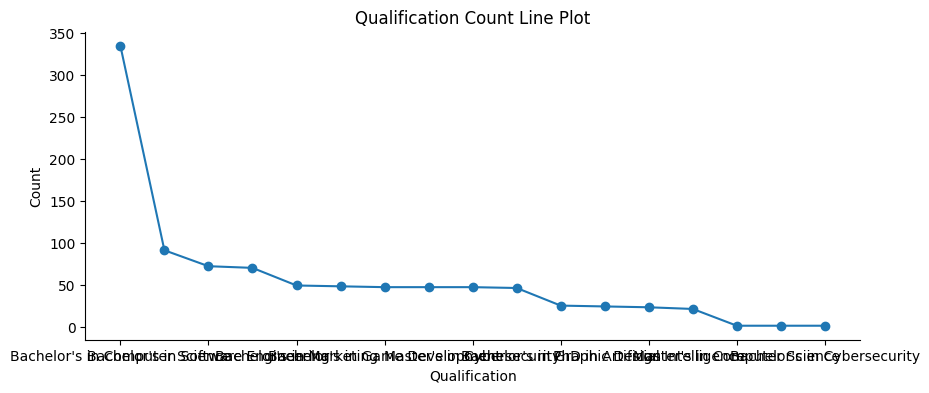

In [ ]:
df = pd.read_csv("education_job_role.csv")

plt.figure(figsize=(10,4))
df['qualification'].value_counts().plot(kind='line', marker='o')
plt.title("Qualification Count Line Plot")
plt.xlabel("Qualification")
plt.ylabel("Count")
plt.gca().spines[['top','right']].set_visible(False)
plt.show()

In [ ]:

import pandas as pd
from google.colab import files

In [ ]:
cleaned_df.to_csv('cleaned_df.csv', index=False)

In [ ]:

files.download('cleaned_df.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
value_counts = df['job_role'].value_counts()

print(value_counts)

job_role
Mobile Developer                  73
Designer                          49
HR                                49
Kubernetes Operations Engineer    48
Game Developer                    48
Backend Developer                 47
Data Analyst                      47
PHP Developer                     47
Software Project Manager          47
Full Stack Python Developer       47
C# Developer                      47
Marketing                         47
Full Stack Java Developer         47
DevOps Engineer                   47
Web Developer                     46
Frontend Developer                46
Data Scientist                    46
Blockchain Developer              46
Cybersecurity Engineer            46
AIML                              23
Finance                            1
Video Game Designer                1
Name: count, dtype: int64
